# xG Performance Analysis
In this notebook we will analyze which players over performed their xG in Laliga seaosn 2024-2025

## Importing Libraries

In [63]:
import re
import requests 
import json 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

from bs4 import BeautifulSoup

## Data source 
I will be using www.understat.com to webscrape Laliga player stats for season 2024-2025. Understat is using JSON for data in their data so we would need to parse JSON in order to get data from understat to store in a DataFrame for further analysis.

In [2]:
response = requests.get('https://understat.com/league/La_liga')
print(response.status_code)

200


In [3]:
soup = BeautifulSoup(response.content,'html.parser')
ugly_soup = str(soup)

In [59]:
# Using regex to get JSON from page source code.
pattern = r"var\s+playersData\s*=\s*JSON\.parse\('([^']+)'\);"

In [5]:
players_data = re.search(pattern, ugly_soup).group(1)

In [6]:
data = players_data.encode('utf8').decode('unicode_escape')

In [7]:
data = json.loads(data)

In [62]:
# JSON Data contains alot of Player details but we will onlt using top ten scorers for our analysis.
data[0:10]

[{'id': '3423',
  'player_name': 'Kylian Mbappe-Lottin',
  'games': '34',
  'time': '2938',
  'goals': '31',
  'xG': '30.135635502636433',
  'assists': '3',
  'xA': '9.394114961847663',
  'shots': '161',
  'key_passes': '51',
  'yellow_cards': '3',
  'red_cards': '1',
  'position': 'F',
  'team_title': 'Real Madrid',
  'npg': '24',
  'npxG': '23.446136973798275',
  'xGChain': '38.313463911414146',
  'xGBuildup': '11.081679956056178'},
 {'id': '227',
  'player_name': 'Robert Lewandowski',
  'games': '34',
  'time': '2716',
  'goals': '27',
  'xG': '29.414338618516922',
  'assists': '2',
  'xA': '2.4752993676811457',
  'shots': '115',
  'key_passes': '18',
  'yellow_cards': '1',
  'red_cards': '0',
  'position': 'F S',
  'team_title': 'Barcelona',
  'npg': '24',
  'npxG': '26.441228091716766',
  'xGChain': '29.242779716849327',
  'xGBuildup': '6.6593545116484165'},
 {'id': '1235',
  'player_name': 'Ante Budimir',
  'games': '38',
  'time': '3008',
  'goals': '21',
  'xG': '20.66943975351

In [10]:
players_stats_Laliga = pd.DataFrame(data[0:10])

In [61]:
# Now this Data Frame contains our Player stats table for season 2024-2025
players_stats_Laliga

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,team_title,npg,npxG,xGChain,xGBuildup,goals_per_90,xg_diff,conversion_rate
0,3423,Kylian Mbappe-Lottin,34,2938,31,30.135636,3,9.394115,161,51,Real Madrid,24,23.446137,38.313464,11.081680,0.949626,0.864364,0.192547
1,227,Robert Lewandowski,34,2716,27,29.414339,2,2.475299,115,18,Barcelona,24,26.441228,29.242780,6.659355,0.894698,-2.414339,0.234783
2,1235,Ante Budimir,38,3008,21,20.669440,4,1.878329,99,16,Osasuna,13,14.723219,14.999034,1.534797,0.628324,0.330560,0.212121
3,6531,Alexander Sørloth,35,1525,20,20.454833,2,1.304561,79,13,Atletico Madrid,19,19.711555,21.536709,2.148046,1.180328,-0.454833,0.253165
4,770,Ayoze Pérez,30,1987,19,15.228043,2,3.127925,75,32,Villarreal,19,15.228043,19.885818,3.779488,0.860594,3.771957,0.253333
5,8026,Raphinha,36,2862,18,19.265995,10,13.527044,114,91,Barcelona,16,17.779440,39.282579,13.650435,0.566038,-1.265995,0.157895
6,10846,Julián Álvarez,37,2543,17,14.159297,4,6.458727,72,41,Atletico Madrid,13,11.186187,25.162181,9.433769,0.601652,2.840703,0.236111
7,7779,Oihan Sancet,29,1645,15,10.459017,1,1.857797,50,21,Athletic Club,12,8.229184,12.246665,4.230631,0.820669,4.540983,0.300000
8,5074,Kike García,35,2571,13,10.712680,0,0.763244,63,13,Alaves,10,8.482847,9.772033,2.098202,0.455076,2.287320,0.206349
9,6933,Javi Puado,35,3023,12,11.945828,4,2.969266,71,22,Espanyol,7,8.229440,13.288859,3.439238,0.357261,0.054172,0.169014


In [12]:
players_stats_Laliga.columns

Index(['id', 'player_name', 'games', 'time', 'goals', 'xG', 'assists', 'xA',
       'shots', 'key_passes', 'yellow_cards', 'red_cards', 'position',
       'team_title', 'npg', 'npxG', 'xGChain', 'xGBuildup'],
      dtype='object')

In [13]:
players_stats_Laliga[players_stats_Laliga['player_name'] == 'Kylian Mbappe-Lottin']

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,yellow_cards,red_cards,position,team_title,npg,npxG,xGChain,xGBuildup
0,3423,Kylian Mbappe-Lottin,34,2938,31,30.135635502636433,3,9.394114961847663,161,51,3,1,F,Real Madrid,24,23.446136973798275,38.313463911414146,11.081679956056178


In [14]:
players_stats_Laliga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            10 non-null     object
 1   player_name   10 non-null     object
 2   games         10 non-null     object
 3   time          10 non-null     object
 4   goals         10 non-null     object
 5   xG            10 non-null     object
 6   assists       10 non-null     object
 7   xA            10 non-null     object
 8   shots         10 non-null     object
 9   key_passes    10 non-null     object
 10  yellow_cards  10 non-null     object
 11  red_cards     10 non-null     object
 12  position      10 non-null     object
 13  team_title    10 non-null     object
 14  npg           10 non-null     object
 15  npxG          10 non-null     object
 16  xGChain       10 non-null     object
 17  xGBuildup     10 non-null     object
dtypes: object(18)
memory usage: 1.5+ KB


## Converting Columns into Numeric for further analysis

In [15]:
players_stats_Laliga = players_stats_Laliga.astype(
    {
      'games' : int, 
      'time' : int,
        'goals' : int,
        'xG':float,
        'assists':int,
        'xA':float,
        'shots':int,
        'key_passes': int, 
        'npg':int,
        'npxG':float,
        'xGChain':float,
        'xGBuildup':float
    }
)

In [16]:
players_stats_Laliga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10 non-null     object 
 1   player_name   10 non-null     object 
 2   games         10 non-null     int32  
 3   time          10 non-null     int32  
 4   goals         10 non-null     int32  
 5   xG            10 non-null     float64
 6   assists       10 non-null     int32  
 7   xA            10 non-null     float64
 8   shots         10 non-null     int32  
 9   key_passes    10 non-null     int32  
 10  yellow_cards  10 non-null     object 
 11  red_cards     10 non-null     object 
 12  position      10 non-null     object 
 13  team_title    10 non-null     object 
 14  npg           10 non-null     int32  
 15  npxG          10 non-null     float64
 16  xGChain       10 non-null     float64
 17  xGBuildup     10 non-null     float64
dtypes: float64(5), int32(7), object(6

In [17]:
players_stats_Laliga.drop(['red_cards','yellow_cards','position'],axis=1,inplace=True)

In [18]:
players_stats_Laliga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           10 non-null     object 
 1   player_name  10 non-null     object 
 2   games        10 non-null     int32  
 3   time         10 non-null     int32  
 4   goals        10 non-null     int32  
 5   xG           10 non-null     float64
 6   assists      10 non-null     int32  
 7   xA           10 non-null     float64
 8   shots        10 non-null     int32  
 9   key_passes   10 non-null     int32  
 10  team_title   10 non-null     object 
 11  npg          10 non-null     int32  
 12  npxG         10 non-null     float64
 13  xGChain      10 non-null     float64
 14  xGBuildup    10 non-null     float64
dtypes: float64(5), int32(7), object(3)
memory usage: 1.0+ KB


In [19]:
players_stats_Laliga['goals_per_90']=players_stats_Laliga['goals'] / players_stats_Laliga['time']*90

In [20]:
players_stats_Laliga.head()

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,team_title,npg,npxG,xGChain,xGBuildup,goals_per_90
0,3423,Kylian Mbappe-Lottin,34,2938,31,30.135636,3,9.394115,161,51,Real Madrid,24,23.446137,38.313464,11.081680,0.949626
1,227,Robert Lewandowski,34,2716,27,29.414339,2,2.475299,115,18,Barcelona,24,26.441228,29.242780,6.659355,0.894698
2,1235,Ante Budimir,38,3008,21,20.669440,4,1.878329,99,16,Osasuna,13,14.723219,14.999034,1.534797,0.628324
3,6531,Alexander Sørloth,35,1525,20,20.454833,2,1.304561,79,13,Atletico Madrid,19,19.711555,21.536709,2.148046,1.180328
4,770,Ayoze Pérez,30,1987,19,15.228043,2,3.127925,75,32,Villarreal,19,15.228043,19.885818,3.779488,0.860594


In [21]:
players_stats_Laliga['xg_diff'] = players_stats_Laliga['goals'] - players_stats_Laliga['xG']

In [22]:
players_stats_Laliga['conversion_rate'] = players_stats_Laliga['goals'] / players_stats_Laliga['shots']

In [23]:
players_stats_Laliga

,id,player_name,games,time,goals,xG,assists,xA,shots,key_passes,team_title,npg,npxG,xGChain,xGBuildup,goals_per_90,xg_diff,conversion_rate
0,3423,Kylian Mbappe-Lottin,34,2938,31,30.135636,3,9.394115,161,51,Real Madrid,24,23.446137,38.313464,11.081680,0.949626,0.864364,0.192547
1,227,Robert Lewandowski,34,2716,27,29.414339,2,2.475299,115,18,Barcelona,24,26.441228,29.242780,6.659355,0.894698,-2.414339,0.234783
2,1235,Ante Budimir,38,3008,21,20.669440,4,1.878329,99,16,Osasuna,13,14.723219,14.999034,1.534797,0.628324,0.330560,0.212121
3,6531,Alexander Sørloth,35,1525,20,20.454833,2,1.304561,79,13,Atletico Madrid,19,19.711555,21.536709,2.148046,1.180328,-0.454833,0.253165
4,770,Ayoze Pérez,30,1987,19,15.228043,2,3.127925,75,32,Villarreal,19,15.228043,19.885818,3.779488,0.860594,3.771957,0.253333
5,8026,Raphinha,36,2862,18,19.265995,10,13.527044,114,91,Barcelona,16,17.779440,39.282579,13.650435,0.566038,-1.265995,0.157895
6,10846,Julián Álvarez,37,2543,17,14.159297,4,6.458727,72,41,Atletico Madrid,13,11.186187,25.162181,9.433769,0.601652,2.840703,0.236111
7,7779,Oihan Sancet,29,1645,15,10.459017,1,1.857797,50,21,Athletic Club,12,8.229184,12.246665,4.230631,0.820669,4.540983,0.300000
8,5074,Kike García,35,2571,13,10.712680,0,0.763244,63,13,Alaves,10,8.482847,9.772033,2.098202,0.455076,2.287320,0.206349
9,6933,Javi Puado,35,3023,12,11.945828,4,2.969266,71,22,Espanyol,7,8.229440,13.288859,3.439238,0.357261,0.054172,0.169014


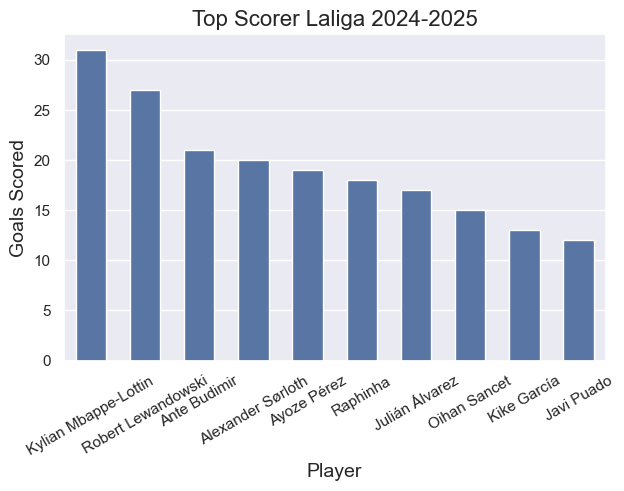

In [29]:
sns.set_theme()
sns.barplot(x='player_name',y='goals',data=players_stats_Laliga,gap=.3)
plt.xticks(rotation=30)  # or 90, 60, etc., depending on your preference
plt.tight_layout()       # Adjust layout to prevent clipping
plt.title('Top Scorer Laliga 2024-2025',fontsize = 16)
plt.xlabel('Player',fontsize=14)
plt.ylabel('Goals Scored',fontsize=14)
plt.show()

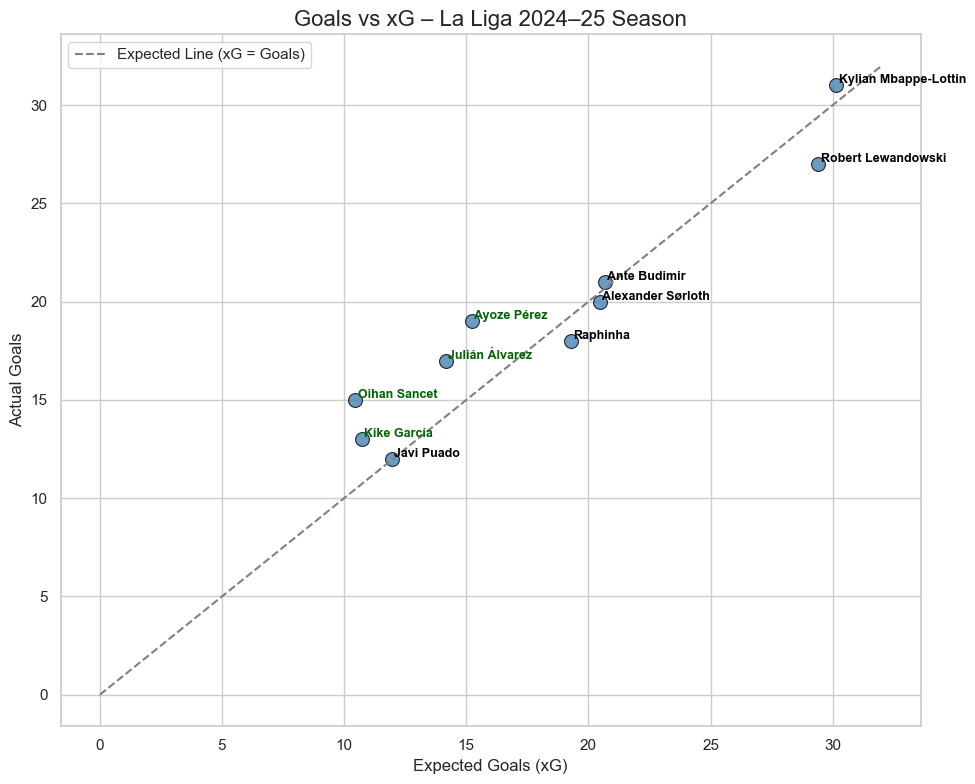

In [58]:
plt.figure(figsize=(10, 8))
sns.set(style='whitegrid')
ax = sns.scatterplot(
    x='xG',
    y='goals',
    data=players_stats_Laliga,
    s=100,
    color='steelblue',
    edgecolor='black',
    alpha=0.8
)

#Creating Line on chart

max_val = max(players_stats_Laliga['xG'].max(), players_stats_Laliga['goals'].max()) + 1
plt.plot([0, max_val], [0, max_val], linestyle='--', color='gray', label='Expected Line (xG = Goals)')

# Highlighting top overperformers
top_overperformers = players_stats_Laliga[players_stats_Laliga['goals'] - players_stats_Laliga['xG'] > 1.5] 
underperformers = players_stats_Laliga[players_stats_Laliga['goals'] - players_stats_Laliga['xG'] < 1.5] 
for i, row in top_overperformers.iterrows():
    plt.text(row['xG']+0.1, row['goals']+0.1, row['player_name'], fontsize=9, color='darkgreen',weight='bold')
for i, row in underperformers.iterrows(): 
    plt.text(row['xG']+0.1, row['goals']+0.1, row['player_name'], fontsize=9, color='black',weight='bold')
# Titles and labels
plt.title('Goals vs xG – La Liga 2024–25 Season', fontsize=16)
plt.xlabel('Expected Goals (xG)', fontsize=12)
plt.ylabel('Actual Goals', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('xG_Performance.png')
plt.show()